In [1]:
!pip install --q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.2 MB/s eta 0:00:00


In [2]:
from ultralytics import RTDETR

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import kagglehub
path = kagglehub.model_download('abeshchakraborty/argus/other/full/1')

In [4]:
import os
model = RTDETR(f"{path}/best.pt")

In [5]:
model.names

{0: 'truck',
 1: 'cyclist',
 2: 'bike',
 3: 'tempo',
 4: 'car',
 5: 'jeep',
 6: 'toto',
 7: 'e-rickshaw',
 8: 'auto-rickshaw',
 9: 'bus',
 10: 'van',
 11: 'cycle-rickshaw',
 12: 'person',
 13: 'taxi'}

In [7]:
model.to("cuda")

RTDETR(
  (model): RTDETRDetectionModel(
    (model): Sequential(
      (0): HGStem(
        (stem1): Conv(
          (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
        (stem2a): Conv(
          (conv): Conv2d(32, 16, kernel_size=(2, 2), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
        (stem2b): Conv(
          (conv): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
        (stem3): Conv(
          (conv): Conv2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001

## Dataset

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arshadrahmanziban/traffic-video-dataset")

print("Path to dataset files:", path)

100%|██████████| 840M/840M [00:12<00:00, 72.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arshadrahmanziban/traffic-video-dataset/versions/1


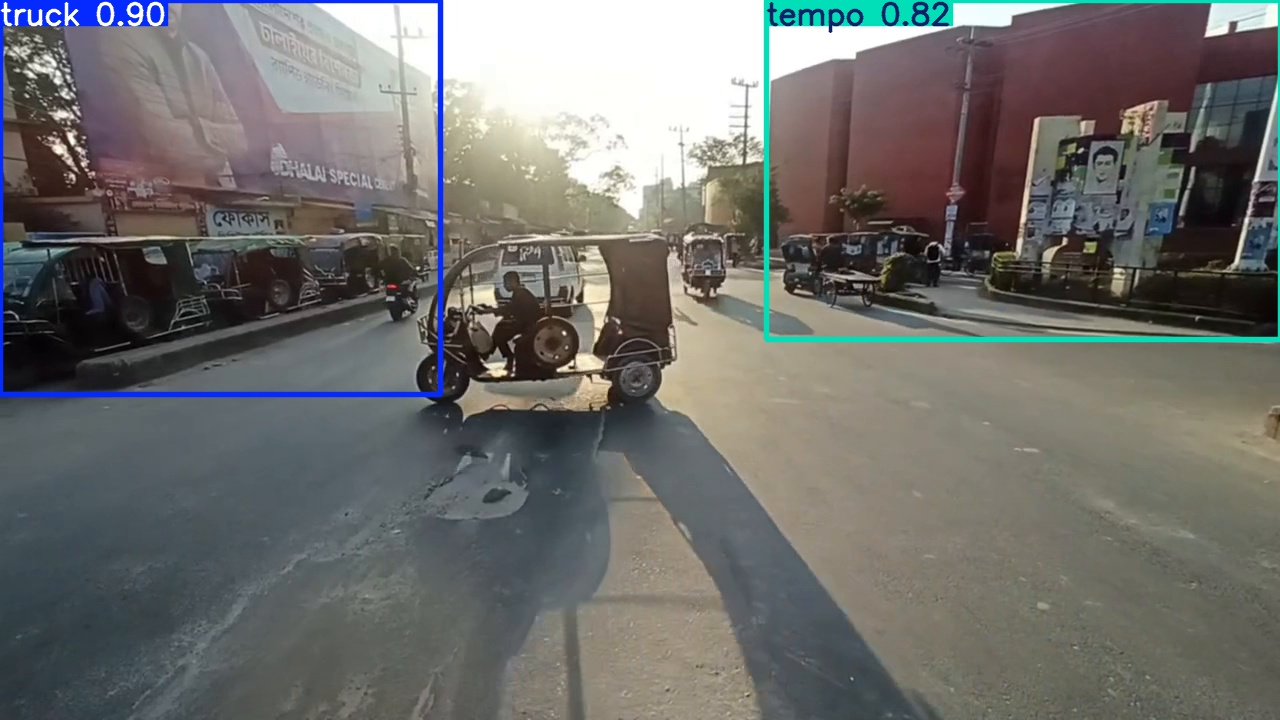

video 1/1 (frame 61/5102) /root/.cache/kagglehub/datasets/arshadrahmanziban/traffic-video-dataset/versions/1/Talaimari/Weast.mp4: 640x640 1 truck, 1 tempo, 3379.1ms

--- Detection Summary ---
Total items detected across 10 seconds: 212
car: 45
truck: 62
tempo: 55
bike: 50


In [13]:
import glob
import os
import cv2
from IPython.display import display, Image, clear_output
from collections import Counter

# Find video files
video_files = glob.glob(os.path.join(path, '**/*.mp4'), recursive=True)

if video_files:
    video_path = video_files[6]
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    max_frames = int(fps * 2)  # 10 seconds of video

    all_detections = []
    frame_count = 0

    print(f"Processing 10 seconds of: {video_path}")

    # Use stream=True to process frames live
    results = model.predict(source=video_path, stream=True, conf=0.70)

    try:
        for r in results:
            if frame_count >= max_frames:
                break

            # Track classes for summary
            classes = r.boxes.cls.cpu().numpy().astype(int)
            all_detections.extend([model.names[c] for c in classes])

            # Plot results on frame
            im_bgr = r.plot()

            # Convert to RGB for IPython display
            im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
            _, buffer = cv2.imencode('.jpg', im_bgr)

            # Display frame live
            clear_output(wait=True)
            display(Image(data=buffer))

            frame_count += 1
    except KeyboardInterrupt:
        pass
    finally:
        cap.release()

    # Print detection summary
    counts = Counter(all_detections)
    print("\n--- Detection Summary ---")
    print(f"Total items detected across 10 seconds: {len(all_detections)}")
    for obj, count in counts.items():
        print(f"{obj}: {count}")
else:
    print("No video files found.")

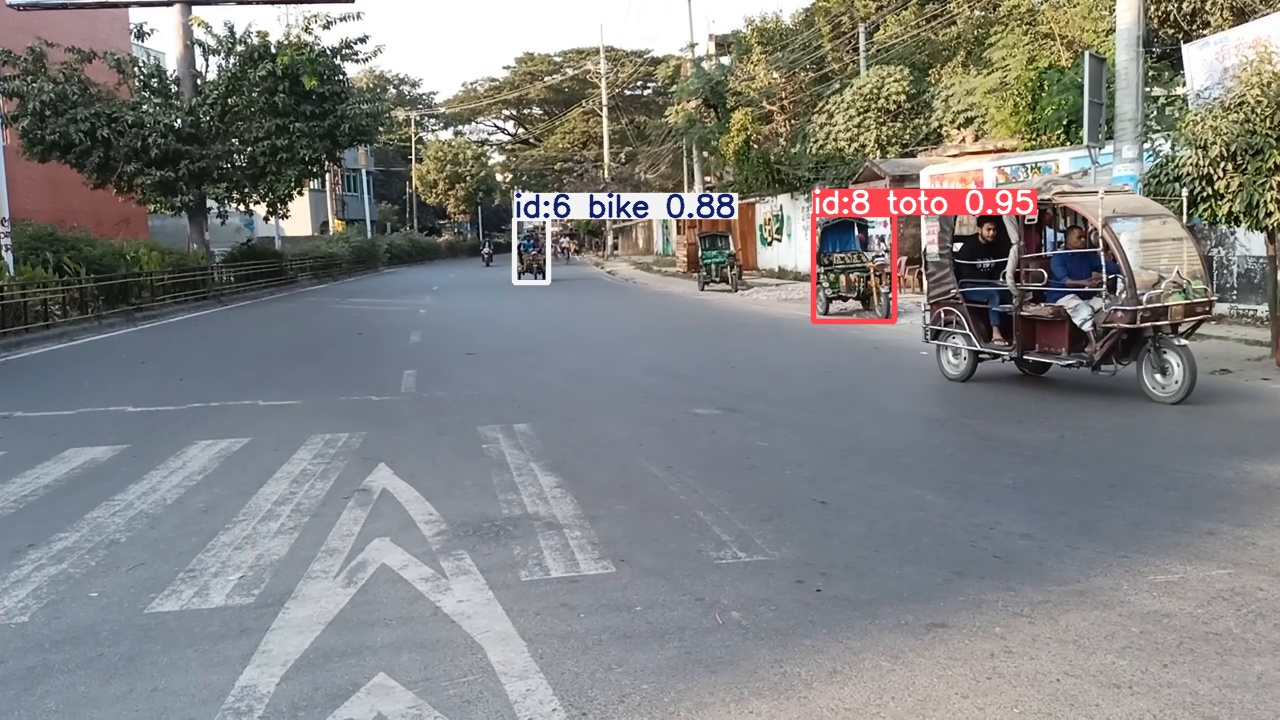

video 1/1 (frame 61/5108) /kaggle/input/traffic-video-dataset/Talaimari/North-East.mp4: 640x640 1 bike, 1 toto, 62.9ms

--- ByteTrack Unique Detection Summary ---
Total UNIQUE items tracked: 6
cyclist: 1
person: 1
auto-rickshaw: 1
bike: 2
toto: 1


In [ ]:
import glob
import os
import cv2
from IPython.display import display, Image, clear_output
from collections import Counter

# Assuming 'path' and 'model' are defined earlier in your Colab notebook
video_files = glob.glob(os.path.join(path, '**/*.mp4'), recursive=True)

if video_files:
    video_path = video_files[6]  # Using the same video as before
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)

    # FIX: Changed from fps * 2 to fps * 10 to match your 10-second comment
    max_frames = int(fps * 2)

    # FIX: Use a dictionary to store {tracker_id: class_name}
    unique_tracked_objects = {}
    frame_count = 0

    print(f"Processing tracking (ByteTrack) for 10 seconds of: {video_path}")

    # Use .track() with ByteTrack configuration
    results = model.track(source=video_path, stream=True, conf=0.7, tracker='bytetrack.yaml')

    try:
        for r in results:
            if frame_count >= max_frames:
                break

            # FIX: Python uses 'None', not 'null'
            if r.boxes.id is not None:
                # Extract both classes and unique IDs
                classes = r.boxes.cls.cpu().numpy().astype(int)
                ids = r.boxes.id.cpu().numpy().astype(int)

                # Pair up each ID with its Class for this frame
                for track_id, cls_id in zip(ids, classes):
                    # If we haven't seen this ID before, record it!
                    if track_id not in unique_tracked_objects:
                        unique_tracked_objects[track_id] = model.names[cls_id]

            # Plot results on frame
            im_bgr = r.plot()

            # Display frame live (Standard Colab workaround)
            _, buffer = cv2.imencode('.jpg', im_bgr)
            clear_output(wait=True)
            display(Image(data=buffer))

            frame_count += 1

    except KeyboardInterrupt:
        pass
    finally:
        cap.release()

    # Print detection summary based on UNIQUE tracking IDs
    # We only count the values (class names) inside our dictionary
    counts = Counter(unique_tracked_objects.values())

    print("\n--- ByteTrack Unique Detection Summary ---")
    print(f"Total UNIQUE items tracked: {len(unique_tracked_objects)}")
    for obj, count in counts.items():
        print(f"{obj}: {count}")
else:
    print("No video files found.")

## Different Dataset

In [5]:
import kagglehub
data = kagglehub.dataset_download("asfakali2/iruvd-dataset-for-automatic-vehicle-detection")

100%|██████████| 2.55G/2.55G [00:29<00:00, 93.4MB/s]


Extracting files...


In [8]:
data

'/root/.cache/kagglehub/datasets/asfakali2/iruvd-dataset-for-automatic-vehicle-detection/versions/1'

Running inference on: /root/.cache/kagglehub/datasets/asfakali2/iruvd-dataset-for-automatic-vehicle-detection/versions/1/JU_yolov5/valid/images/3511.jpg

image 1/1 /root/.cache/kagglehub/datasets/asfakali2/iruvd-dataset-for-automatic-vehicle-detection/versions/1/JU_yolov5/valid/images/3511.jpg: 640x640 2 bikes, 4 cars, 1 auto-rickshaw, 1 bus, 4 persons, 2347.9ms
Speed: 6.9ms preprocess, 2347.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


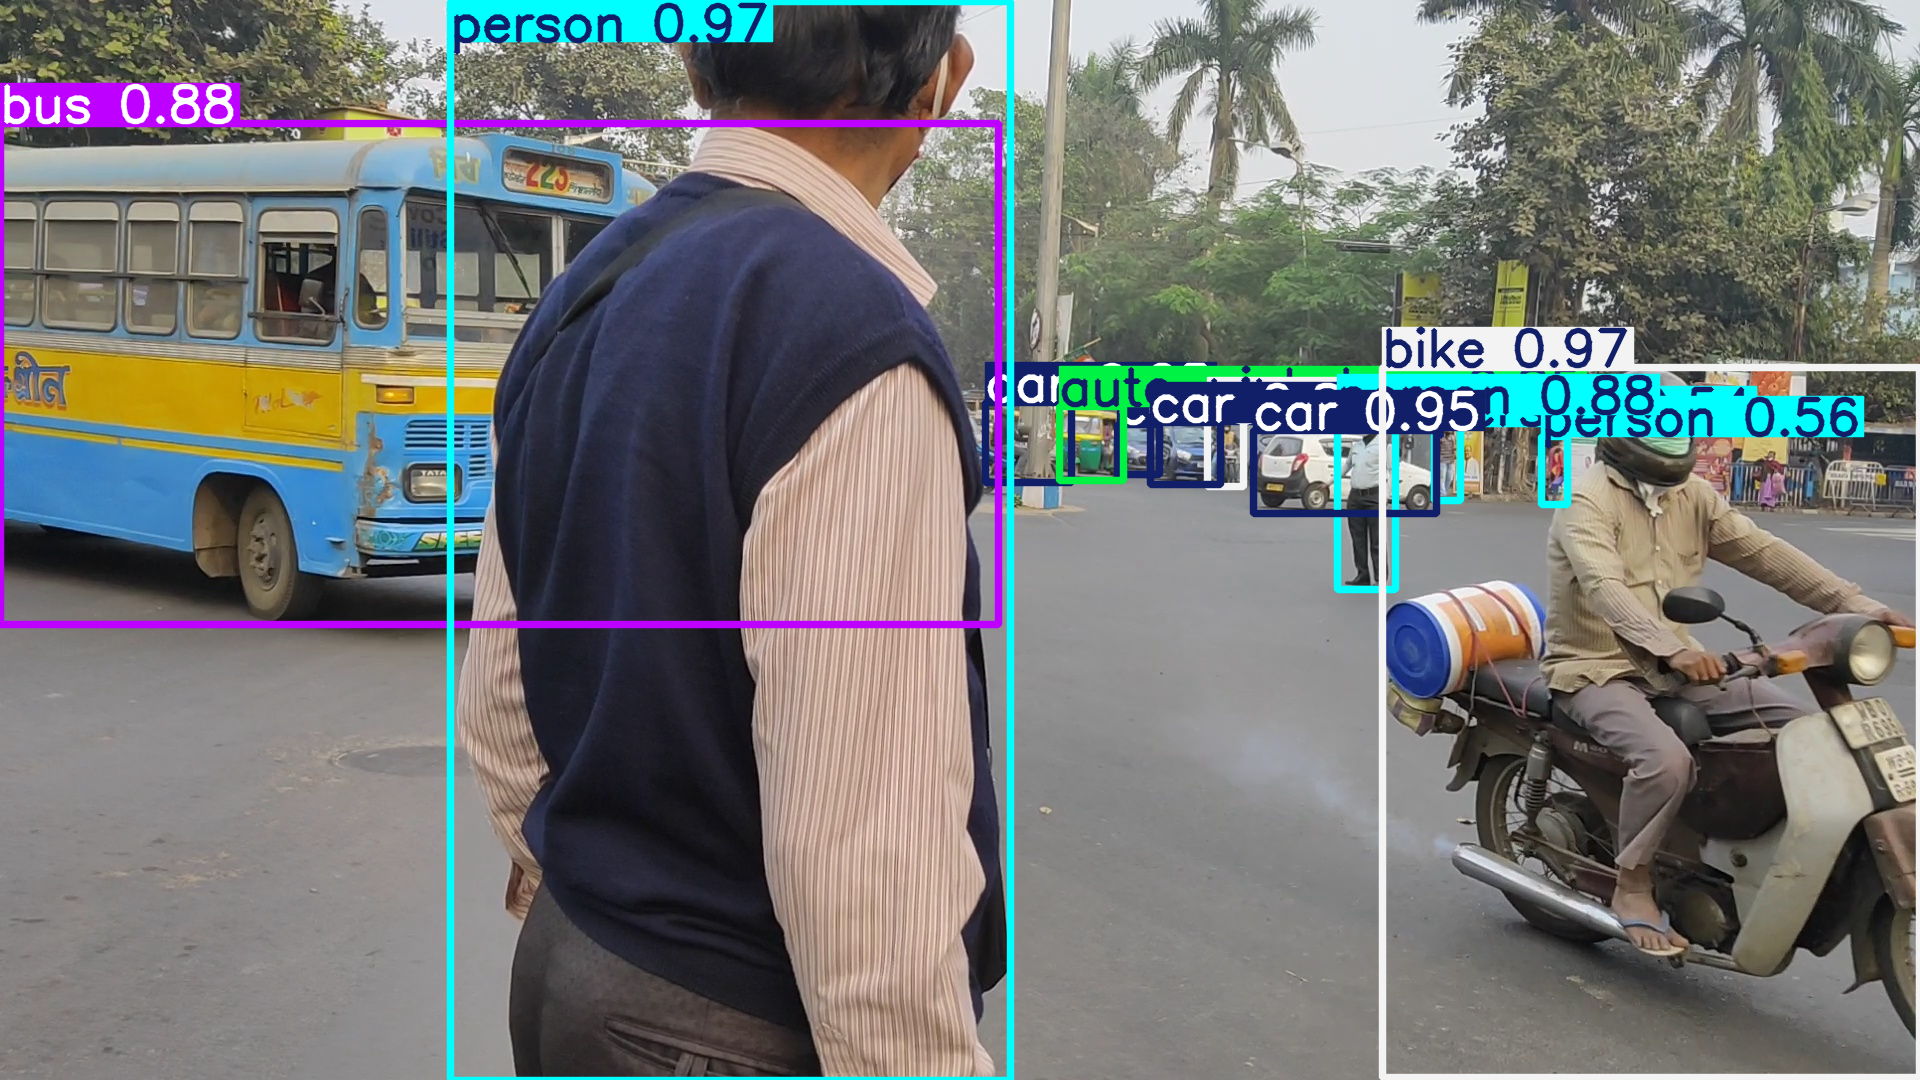

In [11]:
import os
import random
import glob
from PIL import Image
from IPython.display import display

val_images_path = f"/root/.cache/kagglehub/datasets/asfakali2/iruvd-dataset-for-automatic-vehicle-detection/versions/1/JU_yolov5/valid/images"

image_files = glob.glob(os.path.join(val_images_path, '*.jpg')) + \
              glob.glob(os.path.join(val_images_path, '*.png')) + \
              glob.glob(os.path.join(val_images_path, '*.jpeg'))

if image_files:
    random_image = random.choice(image_files)
    print(f"Running inference on: {random_image}")

    results = model.predict(source=random_image, conf=0.25)
    for r in results:
        im_array = r.plot()
        im = Image.fromarray(im_array[..., ::-1])
        display(im)
else:
    print(f"No images found in {val_images_path}. Please check the dataset structure.")

In [ ]:
img_path = "/images.jpg"

In [17]:
results = model.predict(source="/content/images.jpg", conf=0.25)

# Display results
for i, r in enumerate(results):
    # Plot predictions on image
    im_array = r.plot()  # BGR image
    im = Image.fromarray(im_array[..., ::-1])  # convert BGR → RGB

    print(f"--- Prediction {i+1} ---")
    display(im)

    # Print prediction details
    print("Detected classes:", [r.names[int(c)] for c in r.boxes.cls])
    print("Confidence scores:", r.boxes.conf.tolist())
    print("Bounding boxes (xyxy):", r.boxes.xyxy.tolist())

KeyboardInterrupt: 